## Olink Cross-sectional analysis

### Aim 1: Healthy (CON) | At-risk (ARI)

Analysis by Mark Gillespie  
Subset for CertPro by Lucas Graybuck

In [1]:
quiet_library <- function(...) { suppressPackageStartupMessages(library(...)) }

In [2]:
# Data retrieval and upload
quiet_library(hise)
# Functional programming and parallelization
quiet_library(purrr)
quiet_library(furrr)
# Data frame tools
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
# Multiple hypothesis correction
quiet_library(qvalue)
# Plotting
quiet_library(ggplot2)
quiet_library(ggrepel)

In [3]:
plan(multisession, workers = 12)

In [4]:
if(!dir.exists("output")) {
    dir.create("output")
}
out_files <- list()

In [5]:
cache_uuid_path <- function(uuid) {
    cache_path = paste0("cache/", uuid)
    if(!dir.exists(cache_path)) {
        cacheFiles(list(uuid))
    }
    cache_file = list.files(cache_path, full.names = TRUE)
    cache_file
}

In [6]:
qval <- function(df){
    
    a <- qvalue(df$`Pr(>|t|)`)
    
    df <- df %>%
        mutate(qval = a$qvalues, 
               localFDR = a$lfdr)
}

## Read and structure data

Read Olink data

In [7]:
olink_uuid <- "4bbd7e17-607f-4568-a7d2-8190a6eb0c59"
olink_file <- cache_uuid_path(olink_uuid)

In [8]:
olink <- read.csv(olink_file)

In [9]:
length(unique(olink$sample.sampleKitGuid))

[1] 82

Read Metadata from HISE

In [10]:
meta_uuid <- "32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"

In [11]:
meta_file <- cache_uuid_path(meta_uuid)
meta <- read.csv(meta_file)

In [12]:
new_columns <- setdiff(names(meta), names(olink))

meta <- meta %>%
  select(sample.sampleKitGuid, one_of(new_columns))

Combine metadata with olink data

In [13]:
risk <- olink %>%
  left_join(meta, by = "sample.sampleKitGuid")

## Final Model of protein expression: HC vs. All At-risk
Linear model <br>
Covariates = Age, sex, BMI

In [14]:
# Split the data by Olink ID
split_data <- split(risk, risk$OlinkID)

Linear model for comparison. Age, biological sex, and BMI are used as co-variates.

In [15]:
# model
modelRisk <- future_map2(
    split_data, names(split_data), 
    function(df1, mk){
    
    fit <- lm(NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI, # order does not matter for linear model
              data = df1)
    
    fitSummary <- summary(fit)$coef %>%
        as.data.frame() %>% 
        rownames_to_column(var = 'variable') %>%
        filter(!variable == '(Intercept)') %>%
        select(variable, 
               Estimate, 
              `Pr(>|t|)`) %>%
        mutate(OlinkID = mk)
    
    return(fitSummary)
})

paste0('Number of protein assays = ', length(split_data))

[1] "Number of protein assays = 1327"

In [16]:
# all covariate data
fitDF <- bind_rows(modelRisk) %>%
    as.data.frame() %>%
    mutate(Assay = risk$Assay[match(OlinkID, 
                                   table = risk$OlinkID)],
           Assay_OID = risk$Assay_OID[match(OlinkID, 
                                            table = risk$OlinkID)],
           UniProt = risk$UniProt[match(OlinkID, 
                                        table = risk$OlinkID)],
           UniProt_OID = risk$UniProt_OID[match(OlinkID, 
                                                table = risk$OlinkID)]) %>% 
    arrange(`Pr(>|t|)`)


cat('Output: All Variables')
cat('\n\n')
head(fitDF)
nrow(fitDF)
table(fitDF$variable)

Output: All Variables



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ageAtDraw,0.03011055,2.384976e-17,OID20254,LTBP2,LTBP2_OID20254,Q14767,Q14767_OID20254
2,ageAtDraw,0.03292773,3.725688e-17,OID21451,EDA2R,EDA2R_OID21451,Q9HAV5,Q9HAV5_OID21451
3,ageAtDraw,0.03379675,4.592240e-14,OID20622,CXCL17,CXCL17_OID20622,Q6UXB2,Q6UXB2_OID20622
4,ageAtDraw,0.02315118,1.840495e-13,OID20460,WNT9A,WNT9A_OID20460,O14904,O14904_OID20460
5,BMI,0.15692855,3.196113e-13,OID20187,LEP,LEP_OID20187,P41159,P41159_OID20187
6,ageAtDraw,0.02299067,7.280174e-13,OID21048,SCARF2,SCARF2_OID21048,Q96GP6,Q96GP6_OID21048


[1] 5308


                ageAtDraw                       BMI        Status_Xsecat_risk 
                     1327                      1327                      1327 
subject.biologicalSexMale 
                     1327 

In [17]:
all_variables_out <- paste0(
    "output/",
    Sys.Date(),
    "_Risk_lm_allVariables.csv"
)

write.csv(fitDF, 
          all_variables_out, 
          row.names = F)

out_files <- c(out_files, all_variables_out)

In [18]:
# Risk status data only

modelRiskDF <- fitDF %>%
    filter(variable == 'Status_Xsecat_risk')


# Calculate q values (function defined earlier)

modelRiskDF <- qval(modelRiskDF) %>%
    mutate(pcat = ifelse(Estimate > 0 & qval <= 0.1, 
                         'Up', # because ARI - ALTRA_hc
                         ifelse(Estimate < 0 & qval <= 0.1, 
                                'Down', 
                                'NS'))) %>%
    arrange(qval)


# In linear model, first factor alphabetically (ALTRA_healthy) is reference group
# Therefore, upregulated proteins in at_risk samples will be positive


cat('Output: Status Variable')
cat('\n\n')
head(modelRiskDF)
nrow(modelRiskDF)
table(modelRiskDF$variable)

Output: Status Variable



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,localFDR,pcat
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,Status_Xsecat_risk,1.0890537,3.500063e-12,OID20427,IL1B,IL1B_OID20427,P01584,P01584_OID20427,2.144259e-09,8.461767e-06,Up
2,Status_Xsecat_risk,0.6189482,9.064767e-09,OID20569,CCL28,CCL28_OID20569,Q9NRJ3,Q9NRJ3_OID20569,2.776694e-06,8.461767e-06,Up
3,Status_Xsecat_risk,1.0241385,4.405938e-08,OID20542,SCRN1,SCRN1_OID20542,Q12765,Q12765_OID20542,8.039096e-06,2.732907e-05,Up
4,Status_Xsecat_risk,0.7649266,5.248869e-08,OID20520,HLA-DRA,HLA-DRA_OID20520,P01903,P01903_OID20520,8.039096e-06,3.167301e-05,Up
5,Status_Xsecat_risk,1.2796166,5.474550e-07,OID20068,TIA1,TIA1_OID20068,P31483,P31483_OID20068,5.395956e-05,2.504648e-04,Up
6,Status_Xsecat_risk,0.3886610,5.848875e-07,OID21305,DPEP2,DPEP2_OID21305,Q9H4A9,Q9H4A9_OID21305,5.395956e-05,2.658961e-04,Up


[1] 1327


Status_Xsecat_risk 
              1327 

In [19]:
risk_variables_out <- paste0(
    "output/",
    Sys.Date(),
    "_Risk_lm_riskVariable.csv"
)

write.csv(modelRiskDF, 
          risk_variables_out, 
          row.names = F)

out_files <- c(out_files, risk_variables_out)

#### Output for visualization

In [20]:
ari <- modelRiskDF %>%
    mutate(Aim = 'Aim1', 
           Analysis = 'Olink DA', 
           CellType = 'Blood plasma', 
           Method = 'lm', 
           Formula = 'NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI', 
           N = '37 ALTRA_healthy; 45 at_risk') %>%
    select(Aim, 
           Analysis, 
           CellType, 
           Assay_OID, 
           variable, 
           `Pr(>|t|)`, 
           qval, 
           Estimate, 
           Method, 
           Formula, 
           N) %>%
    rename(Feature = Assay_OID, 
           Covariate = variable, 
           NomP = `Pr(>|t|)`, 
           AdjP = qval, 
           EffectSize = Estimate)


head(ari)

,Aim,Analysis,CellType,Feature,Covariate,NomP,AdjP,EffectSize,Method,Formula,N
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,Aim1,Olink DA,Blood plasma,IL1B_OID20427,Status_Xsecat_risk,3.500063e-12,2.144259e-09,1.0890537,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
2,Aim1,Olink DA,Blood plasma,CCL28_OID20569,Status_Xsecat_risk,9.064767e-09,2.776694e-06,0.6189482,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
3,Aim1,Olink DA,Blood plasma,SCRN1_OID20542,Status_Xsecat_risk,4.405938e-08,8.039096e-06,1.0241385,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
4,Aim1,Olink DA,Blood plasma,HLA-DRA_OID20520,Status_Xsecat_risk,5.248869e-08,8.039096e-06,0.7649266,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
5,Aim1,Olink DA,Blood plasma,TIA1_OID20068,Status_Xsecat_risk,5.474550e-07,5.395956e-05,1.2796166,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
6,Aim1,Olink DA,Blood plasma,DPEP2_OID21305,Status_Xsecat_risk,5.848875e-07,5.395956e-05,0.3886610,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk


In [21]:
covar <- fitDF %>%
    filter(variable != 'Status_Xsecat_risk') %>%
    mutate(Aim = 'Aim1', 
           Analysis = 'Olink DA', 
           CellType = 'Blood plasma',
           AdjP = NA,
           Method = 'lm', 
           Formula = 'NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI', 
           N = '37 ALTRA_healthy; 45 at_risk') %>%
    select(Aim, 
           Analysis, 
           CellType, 
           Assay_OID, 
           variable, 
           `Pr(>|t|)`,
           AdjP,
           Estimate, 
           Method, 
           Formula, 
           N) %>%
    rename(Feature = Assay_OID, 
           Covariate = variable, 
           NomP = `Pr(>|t|)`, 
           EffectSize = Estimate)


head(covar)

,Aim,Analysis,CellType,Feature,Covariate,NomP,AdjP,EffectSize,Method,Formula,N
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>
1,Aim1,Olink DA,Blood plasma,LTBP2_OID20254,ageAtDraw,2.384976e-17,NA,0.03011055,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
2,Aim1,Olink DA,Blood plasma,EDA2R_OID21451,ageAtDraw,3.725688e-17,NA,0.03292773,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
3,Aim1,Olink DA,Blood plasma,CXCL17_OID20622,ageAtDraw,4.592240e-14,NA,0.03379675,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
4,Aim1,Olink DA,Blood plasma,WNT9A_OID20460,ageAtDraw,1.840495e-13,NA,0.02315118,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
5,Aim1,Olink DA,Blood plasma,LEP_OID20187,BMI,3.196113e-13,NA,0.15692855,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
6,Aim1,Olink DA,Blood plasma,SCARF2_OID21048,ageAtDraw,7.280174e-13,NA,0.02299067,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk


In [22]:
lo <- ari %>%
    bind_rows(covar) %>%
    mutate(AdjP = ifelse(is.na(AdjP), 
                         'ND', 
                         AdjP))


head(lo)
nrow(lo)

,Aim,Analysis,CellType,Feature,Covariate,NomP,AdjP,EffectSize,Method,Formula,N
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,Aim1,Olink DA,Blood plasma,IL1B_OID20427,Status_Xsecat_risk,3.500063e-12,2.14425946589056e-09,1.0890537,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
2,Aim1,Olink DA,Blood plasma,CCL28_OID20569,Status_Xsecat_risk,9.064767e-09,2.77669431033481e-06,0.6189482,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
3,Aim1,Olink DA,Blood plasma,SCRN1_OID20542,Status_Xsecat_risk,4.405938e-08,8.03909583140006e-06,1.0241385,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
4,Aim1,Olink DA,Blood plasma,HLA-DRA_OID20520,Status_Xsecat_risk,5.248869e-08,8.03909583140006e-06,0.7649266,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
5,Aim1,Olink DA,Blood plasma,TIA1_OID20068,Status_Xsecat_risk,5.474550e-07,5.39595556451106e-05,1.2796166,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk
6,Aim1,Olink DA,Blood plasma,DPEP2_OID21305,Status_Xsecat_risk,5.848875e-07,5.39595556451106e-05,0.3886610,lm,NPX_Final ~ Status_Xsec + ageAtDraw + subject.biologicalSex + BMI,37 ALTRA_healthy; 45 at_risk


[1] 5308

In [23]:
formatted_out <- paste0(
    "output/",
    Sys.Date(),
    "_AtRisk_lm_visualization_format.csv"
)

write.csv(lo, 
          formatted_out, 
          row.names = F)

out_files <- c(out_files, formatted_out)

#### Volcano plot

Warning message:
“ggrepel: 252 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


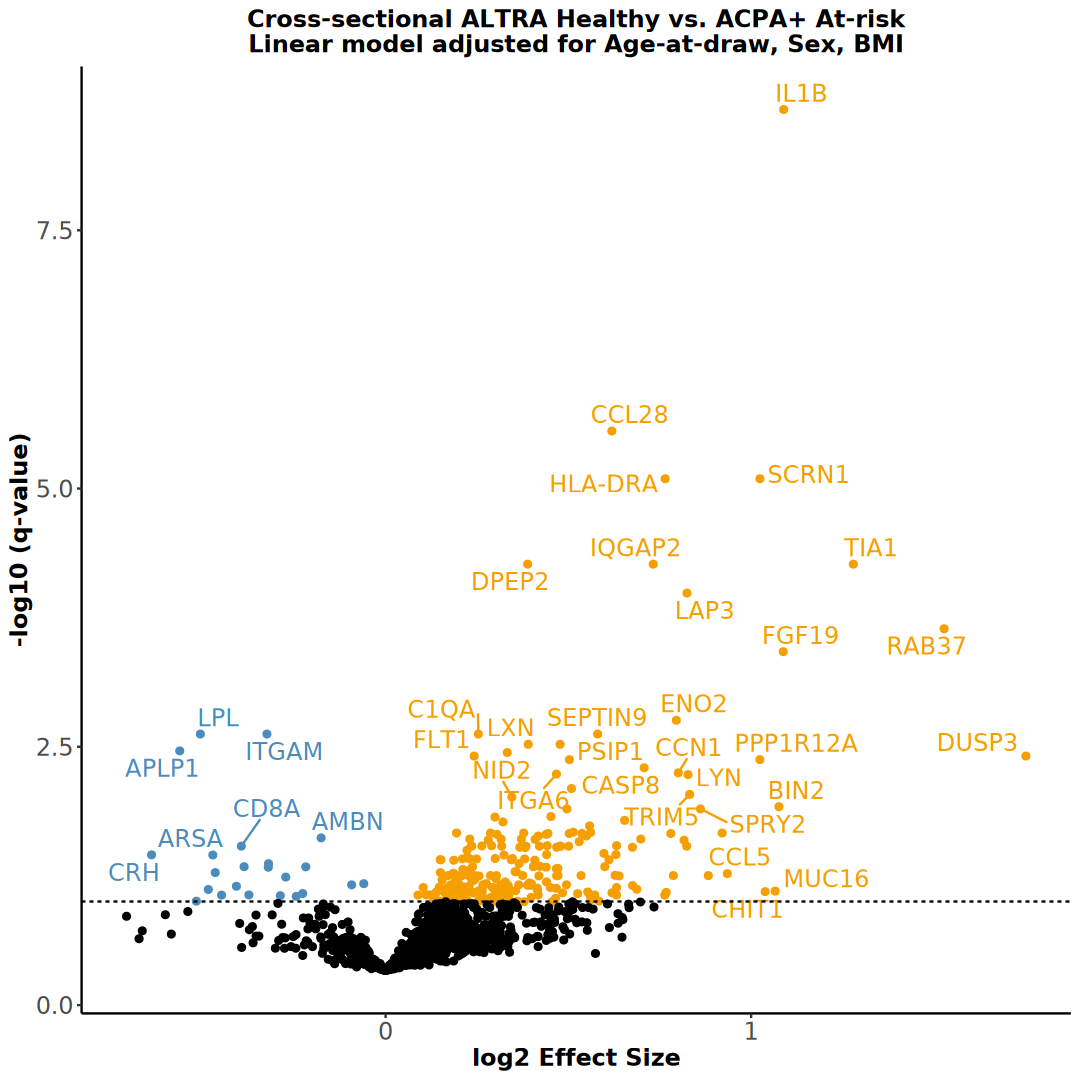

In [24]:
options(repr.plot.width = 9, repr.plot.height = 9)


ggplot(modelRiskDF, aes(x=Estimate,
                        y=-log10(qval), 
                        colour=pcat, 
                        label=ifelse(pcat != 'NS', 
                                     Assay, 
                                     ''))) + 
    geom_point() + 
    geom_text_repel(size = 5) + 
    scale_colour_manual(values = c('#4C8CBD',
                                   'black', 
                                   '#F59F00')) + # NEJM colours 
    geom_hline(yintercept = 1.0, 
               linetype = 'dashed') + # p=0.1 reference mark
    labs(title='Cross-sectional ALTRA Healthy vs. ACPA+ At-risk\nLinear model adjusted for Age-at-draw, Sex, BMI',
         x='log2 Effect Size', 
         y='-log10 (q-value)') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

## Store results in HISE

In order to store the results in HISE, we'll need to cache these files to register them, and then we can upload the CSV files for later steps.

In [25]:
study_space_uuid <- "223de760-9624-45bd-aefe-ca24c75b1800"
title <- paste("ALTRA Olink Results Aim 1: CON | ARI", Sys.Date())

In [26]:
search_id = ids::proquint(n_words = 3)
search_id

[1] "zahin-totok-popin"

In [27]:
in_list <- list(olink_uuid, meta_uuid)

In [28]:
out_files

[[1]]
[1] "output/2024-10-22_Risk_lm_allVariables.csv"

[[2]]
[1] "output/2024-10-22_Risk_lm_riskVariable.csv"

[[3]]
[1] "output/2024-10-22_AtRisk_lm_visualization_format.csv"

In [29]:
uploadFiles(
    files = out_files,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    destination = search_id,
    store = "project",
    doPrompt = FALSE
)

[1] "Cannot determine the current notebook."
[1] "1) /home/jupyter/ra-longitudinal/olink/aim1/01-R_aim1_ARI_vs_CON_modeling.ipynb"
[1] "2) /home/jupyter/ra-longitudinal/olink/aim3/aim3-13_FinalModel_updatedsamples_gte750days.ipynb"
[1] "3) /home/jupyter/ra-longitudinal/olink/aim3/aim3-02_ReviewCompiledOlink.ipynb"


Please select (1-3)  1


$files
$files[[1]]
[1] "output/2024-10-22_Risk_lm_allVariables.csv"

$files[[2]]
[1] "output/2024-10-22_Risk_lm_riskVariable.csv"

$files[[3]]
[1] "output/2024-10-22_AtRisk_lm_visualization_format.csv"


$traceId
[1] "284d2e52-a179-4aab-a1b3-39f9c5cf951b"

## Session Info

In [30]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /opt/conda/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.4 ggplot2_3.5.1 qvalue_2.34.0 tibble_3.2.1  tidyr_1.3.0  
 [6] dplyr_1.1.4   furrr_0.3.1   future_1.33.1 purrr_1.0.2   hise_2.16.0  

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    bitops_1.0-7      stringi_1.8.3    
 [5] listenv_0.9.0     digest_0.6.36     m